# Experiment 3: Large-Scale Simulation Study

This notebook reproduces the findings from the paper's comprehensive simulation study, specifically visualizing the results presented in the section "**How robust are the different methods**". While the previous experiments utilized a single, controlled dataset, this experiment systematically evaluates the five Bayesian models across 48 distinct statistical scenarios to rigorously quantify their performance. 

For each scenario, we generated $1000$ independent datasets across a grid of varying conditions:
- Sample Sizes ($N$): 20, 50, 100, and 250
- Contamination Proportions: $0.0$ to $0.5$ (in increments of $0.1$)
- Contamination Types: Unbiased (symmetric) and Biased (asymmetric)

Dataset generation script can be found in `/data/generate_simulation_data.py`

Using these $48000$ datasets, this notebook visualizes two critical metrics:
1. Coverage Probability (Figure 7): THe percentage of time the model's 95% credible interval successfully captures the true underlying population mean.
2. Average Credible Interval Width (Figure 8): The average uncertainty bounds of the model, illustrating the "robustness tax" (how much precision is lost to maintain accuracy).

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Import helper function from the src directory
from src.inference.runner import (
    run_parametric_parallel_mcmc, 
    run_nonparametric_vectorized
)

# Import models from the src directory
from src.models import (
    normal_model,
    contaminated_normal_model,
    student_t_model,
    bayesian_bootstrap_mean,
    bayesian_bootstrap_trimmed
)

/Users/yumin/Documents/Research/PML/Repository/credible-intervals-jax/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Implementation

Run vectorized MCMC and Bayesian Bootstrap on $1000$ datasets across the 48 different data configurations each on the 5 models.

In [2]:
from jax._src.numpy import tensor_contractions
# 1. Define the experiment grid
sample_sizes = [20, 50, 100, 250]
proportions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
contamination_types = ["unbiased", "biased"]
data_dir = "../data"

MCMC_SAMPLES = 1000
MCMC_WARMUP = 500

results = []

total_iterations = len(sample_sizes) * len(proportions) * len(contamination_types)

with tqdm(total=total_iterations, desc="Simulating Scenarios") as pbar:
    for n in sample_sizes:
        for prop in proportions:
            for c_type in contamination_types:

                # 2. Load the batched dataset for this scenario
                filename = f"sim_{c_type}_{int(prop*100)}_{n}.npy"
                filepath = os.path.join(data_dir, filename)

                if not os.path.exists(filepath):
                    print(f"Missing {filename}, skipping...")
                    pbar.update(1)
                    continue
            
                batched_data = jnp.load(filepath)

                # 3. Run Inference
                s_normal = run_parametric_parallel_mcmc(
                    normal_model, batched_data, MCMC_SAMPLES, MCMC_WARMUP
                )
                s_contam = run_parametric_parallel_mcmc(
                    contaminated_normal_model, batched_data, MCMC_SAMPLES, MCMC_WARMUP
                )
                s_student = run_parametric_parallel_mcmc(
                    student_t_model, batched_data, MCMC_SAMPLES, MCMC_WARMUP
                )
                s_bb_mean = run_nonparametric_vectorized(
                    bayesian_bootstrap_mean, batched_data, MCMC_SAMPLES
                )
                s_bb_trim = run_nonparametric_vectorized(
                    bayesian_bootstrap_trimmed, batched_data, MCMC_SAMPLES
                )

                # Dictionary to loop over models easily
                model_samples = {
                    "normal": s_normal,
                    "cont": s_contam,
                    "t": s_student,
                    "BBmean": s_bb_mean,
                    "BBtrim": s_bb_trim
                }

                # 4. Calculate Summary Statistics
                for model_name, samples in model_samples.items():
                    lower = np.percentile(samples, 2.5, axis=1)
                    upper = np.percentile(samples, 97.5, axis=1)

                    coverage = np.mean((lower <=0.0) & (upper >= 0.0))

                    avg_width = np.mean(upper-lower)

                    results.append({
                        "sample_size": n,
                        "contamination_prop": prop,
                        "contamination_type": c_type,
                        "model": model_name,
                        "coverage_probability": coverage,
                        "average_ci_width": avg_width
                    })

                pbar.update(1)
    
# 5. Save the final processed data
df_results = pd.DataFrame(results)
df_results.to_csv("../data/simulation_results.csv", index=False)
print("Simulation complete! Results saved to CSV.")

Simulating Scenarios:   0%|          | 0/48 [00:00<?, ?it/s]

Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing Predictive over 1000 datasets...
Vectorizing Predictive over 1000 datasets...


Simulating Scenarios:   2%|▏         | 1/48 [01:16<59:40, 76.19s/it]

Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing Predictive over 1000 datasets...
Vectorizing Predictive over 1000 datasets...


Simulating Scenarios:   4%|▍         | 2/48 [02:30<57:29, 74.98s/it]

...

Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing Predictive over 1000 datasets...
Vectorizing Predictive over 1000 datasets...


Simulating Scenarios:  98%|█████████▊| 47/48 [1:24:05<02:37, 157.99s/it]

Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing MCMC over 1000 datasets...
Vectorizing Predictive over 1000 datasets...
Vectorizing Predictive over 1000 datasets...


Simulating Scenarios: 100%|██████████| 48/48 [1:27:34<00:00, 109.46s/it]

Simulation complete! Results saved to CSV.


Generating Figure 7: Coverage Probability...


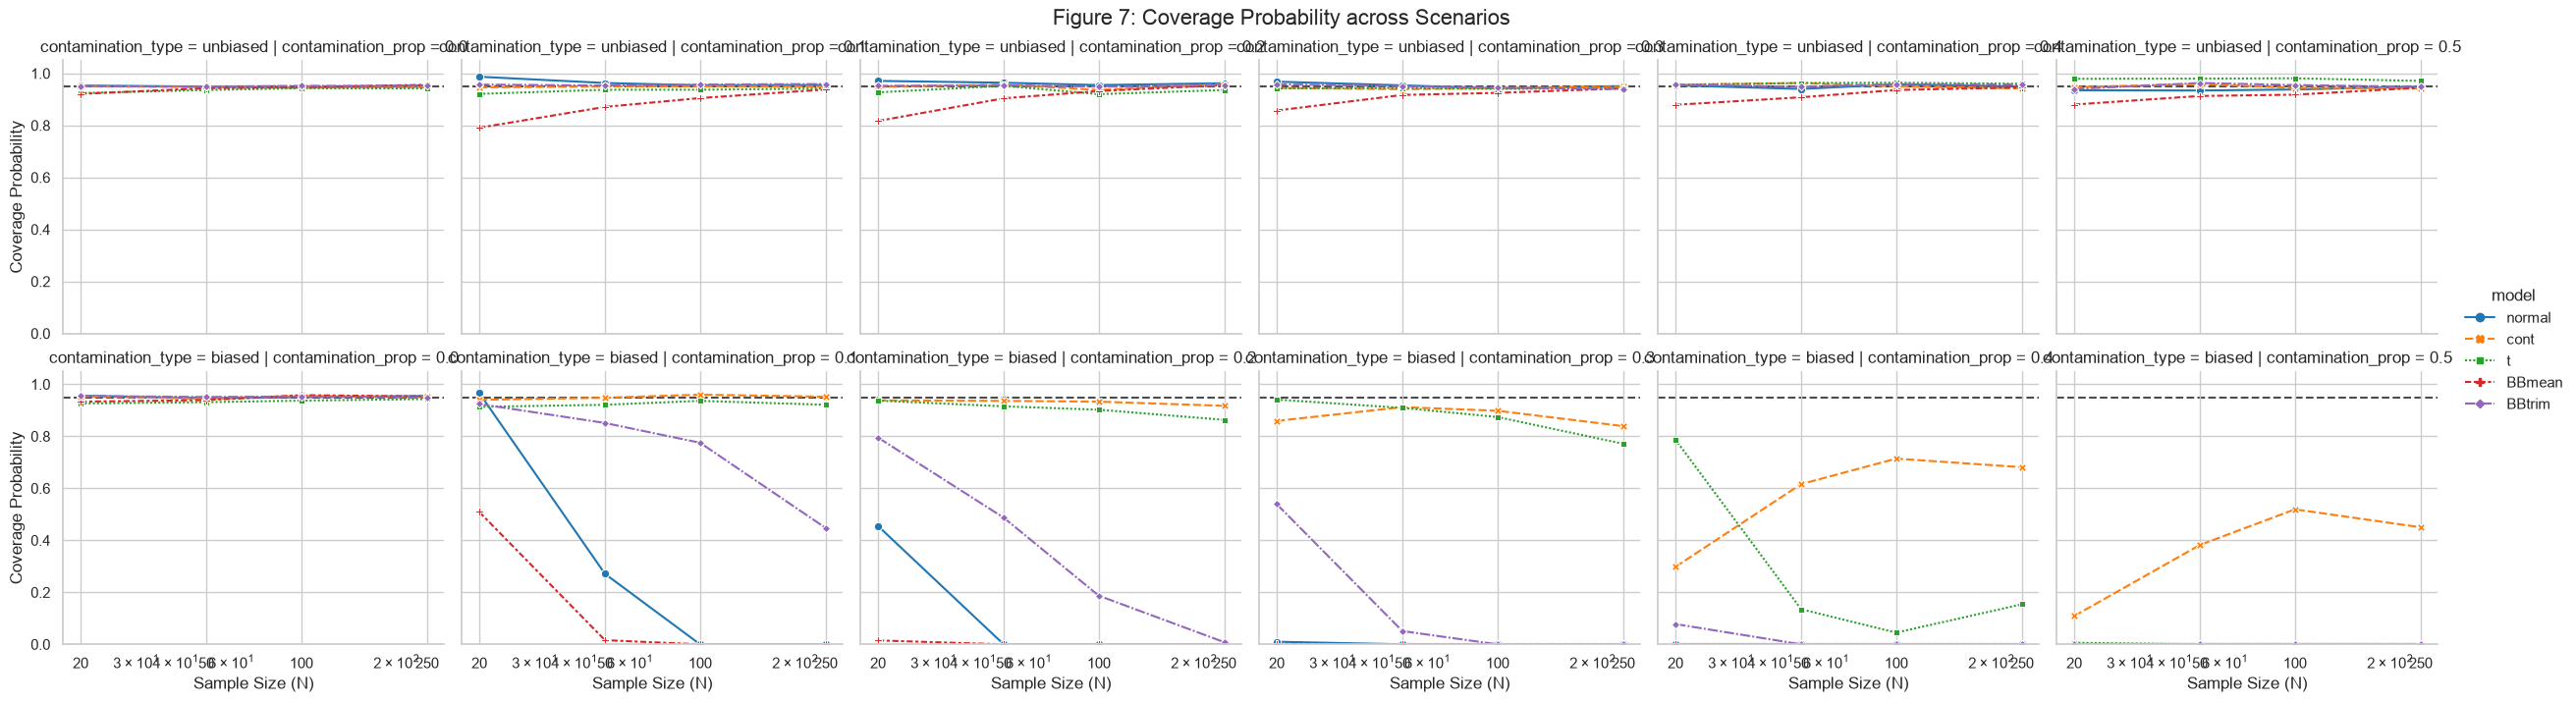

Generating Figure 8: Average Credible Interval Width...


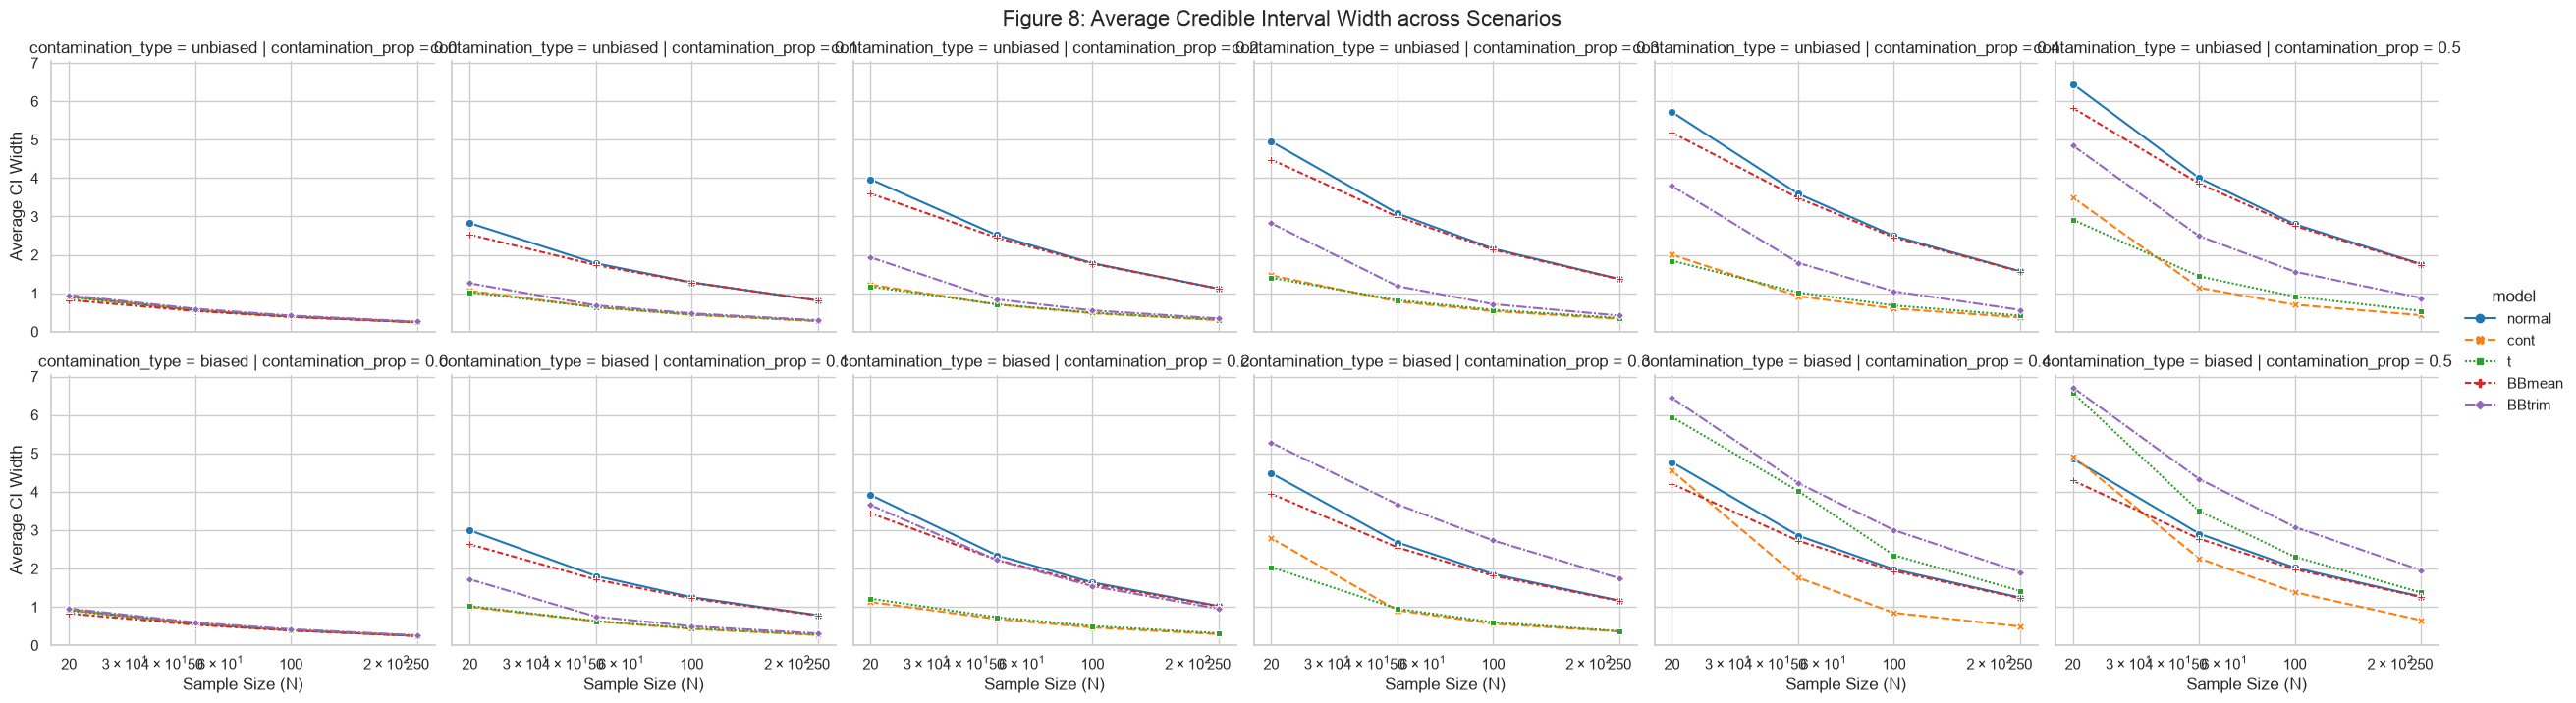

In [6]:
# 1. Load the processed data
df = pd.read_csv("../data/simulation_results.csv")

# Set a clean visual style
sns.set_theme(style="whitegrid")

# ==========================================
# Figure 7: Coverage Probability
# ==========================================
print("Generating Figure 7: Coverage Probability...")

g_cov = sns.relplot(
    data=df,
    x="sample_size",
    y="coverage_probability",
    hue="model",          # Color by model
    style="model",        # Different line styles/markers per model
    col="contamination_prop", 
    row="contamination_type",
    kind="line",
    markers=True,
    height=3.5,
    aspect=1.2,
    palette="tab10"
)

# Add the 95% target line and format axes
for ax in g_cov.axes.flat:
    ax.axhline(0.95, color='black', linestyle='--', alpha=0.7, zorder=0, label="Nominal Target (0.95)")
    ax.set_ylim(0.0, 1.05)
    # Optional: Log scale can make the X-axis easier to read for N=[20, 50, 100, 250]
    ax.set_xscale('log')
    ax.set_xticks([20, 50, 100, 250])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

g_cov.set_axis_labels("Sample Size (N)", "Coverage Probability")
g_cov.fig.suptitle("Figure 7: Coverage Probability across Scenarios", y=1.02, fontsize=16)

plt.show()


# ==========================================
# Figure 8: Average Credible Interval Width
# ==========================================
print("Generating Figure 8: Average Credible Interval Width...")

g_width = sns.relplot(
    data=df,
    x="sample_size",
    y="average_ci_width",
    hue="model",
    style="model",
    col="contamination_prop",
    row="contamination_type",
    kind="line",
    markers=True,
    height=3.5,
    aspect=1.2,
    palette="tab10"
)

# Format axes
for ax in g_width.axes.flat:
    ax.set_ylim(bottom=0.0) # Width can't be negative, but let the top scale naturally
    ax.set_xscale('log')
    ax.set_xticks([20, 50, 100, 250])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

g_width.set_axis_labels("Sample Size (N)", "Average CI Width")
g_width.fig.suptitle("Figure 8: Average Credible Interval Width across Scenarios", y=1.02, fontsize=16)

plt.show()

## Discussion

### The Trade-off Between Efficiency and Robustness

The results visualized in Figures 7 and 8 clearly illustrate the critical dynamics between statistical efficiency and robustness. Figure 7 demonstrates that standard models (like the Normal distribution) suffer a catastrophic collapse in coverage probability when exposed to contaminated data, confidently missing the true population mean entirely. Conversely, robust models—such as the Contaminated Normal and Trimmed Bayesian Bootstrap—successfully maintain their nominal 95% coverage across nearly all contamination scenarios. However, Figure 8 reveals that this mathematical immunity comes with a slight "robustness tax." In perfectly clean data, robust models yield slightly wider credible intervals because they make fewer rigid assumptions. Yet, as contamination grows, this initial tax pays dividends: the robust models maintain stable, efficient bounds, while the non-robust models see their interval widths explode as they artificially inflate their variance to accommodate the outliers.

### Unbiased Contamination (Top row)

Looking at the top row of Fig 7, when the contaminants are unbiased, all four Bayesian methods have reasonable coverage. The only exception being the BB-mean model (plotted in red), which performs noticeably worse than the others when the sample size is small and the contamination level is low.

The top row of Figure 8 suggests that the average width of the credible intervals does not differ greatly among all four methods. Taken together, the reproduced result is in alignment with that of the paper, which reveals that unbiased contaminants are comparatively harmless, having only modest influence on the accuracy or size of the credible intervals.

### Biased Contamination (Bottom row)

In the bottom row of Fig 7, the normal and the BB-mean model are both very sensitive to biased contaminants. The failure of the BB-mean approach reveals that non-parametric approaches are not automatically robust.

The 20% BB-trimmed model unsurprisingly becomes less robust beyond the 20% level of contamination.